# Stage 21 — Attention Analysis

Three-way comparison: M4 (max) / M4-attn (learned attention) / M2 (max).
Answers RQ4 and RQ5 from `plan/execution-plan-v5.md`.

## 1. Imports & Config

In [1]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import (
    make_dataloaders,
    LABEL_NAMES,
    NUM_CLASSES,
    MMWHSPatientDataset,
)
from src.models.proto_seg_net import ProtoSegNet
from src.metrics.proto_quality import (
    compute_purity,
    compute_utilization,
    compute_compactness,
    compute_dice_sensitivity,
    compute_level_dominance,
    compute_per_level_ap,
)
from src.metrics.dice import dice_per_class, mean_foreground_dice

MODALITY = "ct"
DATA_DIR = "data/pack/processed_data"
DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]
LEVEL_COLORS = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
print(f"Device: {DEVICE}")

Device: mps


## 2. Load Models & Dataloaders

In [2]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=16)


def load_model(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    # Older checkpoints store proto_levels=None meaning all 4 levels
    proto_levels = ckpt.get("proto_levels") or [1, 2, 3, 4]
    model = ProtoSegNet(
        n_classes=NUM_CLASSES,
        proto_levels=proto_levels,
        use_level_attention=ckpt.get("use_level_attention", False),
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(
        f"{ckpt_path.split('/')[-1]:<45}  levels={proto_levels}  "
        f"attn={ckpt.get('use_level_attention', False)}  "
        f"best_val={ckpt.get('best_val_dice', float('nan')):.4f}"
    )
    return model


m4 = load_model("checkpoints/proto_seg_ct_l2.pth")
m2 = load_model("checkpoints/proto_seg_ct_l3l4.pth")
m4attn = load_model("checkpoints/proto_seg_ct_l1234_attn.pth")

proto_seg_ct_l2.pth                            levels=[1, 2, 3, 4]  attn=False  best_val=0.8173
proto_seg_ct_l3l4.pth                          levels=[3, 4]  attn=False  best_val=0.8380
proto_seg_ct_l1234_attn.pth                    levels=[1, 2, 3, 4]  attn=True  best_val=0.8164


## 3. 3D Dice Evaluation

In [3]:
@torch.no_grad()
def eval_3d(model, label):
    ds = MMWHSPatientDataset(DATA_DIR, MODALITY, "test")
    all_means = []
    per_class = {n: [] for n in FG_NAMES}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        d = dice_per_class(torch.cat(logits_all), s["label"])
        mfg = mean_foreground_dice(d)
        all_means.append(mfg)
        for n in FG_NAMES:
            per_class[n].append(d.get(n, float("nan")))
    mean_fg = float(np.mean(all_means))
    per_class_mean = {n: float(np.mean(v)) for n, v in per_class.items()}
    print(f"[{label}]  3D Dice = {mean_fg:.4f}")
    return mean_fg, per_class_mean


dice_m4, pc_m4 = eval_3d(m4, "M4      ")
dice_m4attn, pc_m4attn = eval_3d(m4attn, "M4-attn ")
dice_m2, pc_m2 = eval_3d(m2, "M2      ")

print(f"\nΔ M4-attn vs M4 : {dice_m4attn - dice_m4:+.4f}")
print(f"Δ M4-attn vs M2 : {dice_m4attn - dice_m2:+.4f}")

[M4      ]  3D Dice = 0.8407


[M4-attn ]  3D Dice = 0.8483


[M2      ]  3D Dice = 0.8722

Δ M4-attn vs M4 : +0.0076
Δ M4-attn vs M2 : -0.0239


## 4. Proto Quality Metrics — M4-attn

In [4]:
import pathlib, csv

OUT = "results/v5/proto_quality/m4_attn"
pathlib.Path(OUT).mkdir(parents=True, exist_ok=True)

test_loader = loaders["test"]

print("Computing purity…")
purity = compute_purity(m4attn, loaders["train"])
purity.to_csv(f"{OUT}/purity_summary.csv", index=False)

print("Computing utilization…")
util = compute_utilization(m4attn, test_loader)
util.to_csv(f"{OUT}/utilization.csv", index=False)

print("Computing compactness…")
comp = compute_compactness(m4attn, test_loader)
comp.to_csv(f"{OUT}/compactness.csv", index=False)

print("Computing level dominance…")
dom = compute_level_dominance(m4attn, test_loader)
dom.to_csv(f"{OUT}/level_dominance.csv", index=False)

print("Computing per-level AP…")
ap = compute_per_level_ap(m4attn, test_loader)
pd.DataFrame(ap).to_csv(f"{OUT}/per_level_ap.csv", index=False)

print("Done.")
print(
    f"  Purity L4   : {purity[purity['level']==4]['purity'].mean():.3f}"
)

dom_df = pd.read_csv(f"{OUT}/level_dominance.csv")
print(f"  Dominance   : {dom_df.iloc[0].to_dict()}")

ap_df = pd.read_csv(f"{OUT}/per_level_ap.csv")
ap_l4 = ap_df[ap_df["level"] == 4]["ap"].mean()
print(f"  AP L4 (mean): {ap_l4:.3f}")

Computing purity…


Computing utilization…


Computing compactness…


Computing level dominance…


Computing per-level AP…


Done.
  Purity L4   : 0.526
  Dominance   : {'frac_l1': 0.6144906036124742, 'frac_l2': 0.2402726480783509, 'frac_l3': 0.0484799787032702, 'frac_l4': 0.0967567696059045}
  AP L4 (mean): 0.187


## 5. Three-Way Comparison Table: M4 / M4-attn / M2

In [5]:
# Load pre-computed metrics for M4 and M2
def load_purity(path):
    return pd.read_csv(path)


def load_dom(path):
    return pd.read_csv(path).to_dict("records")[0]


def load_ap_l4(path):
    df = pd.read_csv(path)
    return df[df["level"] == 4]["ap"].mean()


def load_comp_l4(path):
    df = pd.read_csv(path)
    return df[df["level"] == 4]["compactness"].mean()


# M4
m4_pur = load_purity("results/v4/proto_quality/v1/purity_summary.csv")
m4_dom = load_dom("results/v4/proto_quality/v1/level_dominance.csv")
m4_ap = load_ap_l4("results/v4/proto_quality/v1/per_level_ap.csv")
m4_comp = load_comp_l4("results/v4/proto_quality/v1/compactness.csv")

# M2
m2_pur = load_purity("results/v4/proto_quality/m2_l3l4/purity_summary.csv")
m2_dom = load_dom("results/v4/proto_quality/m2_l3l4/level_dominance.csv")
m2_ap = load_ap_l4("results/v4/proto_quality/m2_l3l4/per_level_ap.csv")
m2_comp = load_comp_l4("results/v4/proto_quality/m2_l3l4/compactness.csv")

# M4-attn (just computed)
attn_pur = load_purity(f"{OUT}/purity_summary.csv")
attn_dom = load_dom(f"{OUT}/level_dominance.csv")
attn_ap = load_ap_l4(f"{OUT}/per_level_ap.csv")
attn_comp = load_comp_l4(f"{OUT}/compactness.csv")


def pur_l4(df):
    sub = df[df["level"] == 4]
    if "mean" in sub.columns: return sub["mean"].values[0]
    return sub["purity"].mean()  # per-prototype format


rows = {
    "Model": ["M4 (max)", "M4-attn", "M2 (max)"],
    "Levels": ["L1–L4", "L1–L4 + attn", "L3–L4"],
    "Aggregation": ["max", "weighted avg", "max"],
    "3D Dice": [f"{dice_m4:.4f}", f"{dice_m4attn:.4f}", f"{dice_m2:.4f}"],
    "Purity L4": [
        f"{pur_l4(m4_pur):.3f}",
        f"{pur_l4(attn_pur):.3f}",
        f"{pur_l4(m2_pur):.3f}",
    ],
    "Compactness L4": [f"{m4_comp:.3f}", f"{attn_comp:.3f}", f"{m2_comp:.3f}"],
    "AP L4": [f"{m4_ap:.3f}", f"{attn_ap:.3f}", f"{m2_ap:.3f}"],
    "Dominance L4": [
        f"{m4_dom.get('frac_l4', 0) * 100:.1f}%",
        None,
        f"{m2_dom.get('frac_l4', 0) * 100:.1f}%",
    ],
}

# Fix attn dominance key (may be named differently)
attn_dom_vals = list(attn_dom.values())
attn_dom_keys = list(attn_dom.keys())
print("Attn dom keys:", attn_dom_keys)
frac_l4_attn = attn_dom.get("frac_l4", attn_dom_vals[-1] if attn_dom_vals else 0)
rows["Dominance L4"][1] = f"{frac_l4_attn * 100:.1f}%"

df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
df_cmp.to_csv("results/v5/proto_quality/comparison_table.csv", index=False)

Attn dom keys: ['frac_l1', 'frac_l2', 'frac_l3', 'frac_l4']
   Model       Levels  Aggregation 3D Dice Purity L4 Compactness L4 AP L4 Dominance L4
M4 (max)        L1–L4          max  0.8407     0.824          0.573 0.189         4.3%
 M4-attn L1–L4 + attn weighted avg  0.8483     0.526          0.575 0.187         9.7%
M2 (max)        L3–L4          max  0.8722     0.804          0.361 0.236        49.1%


## 6. Attention Weight Distribution

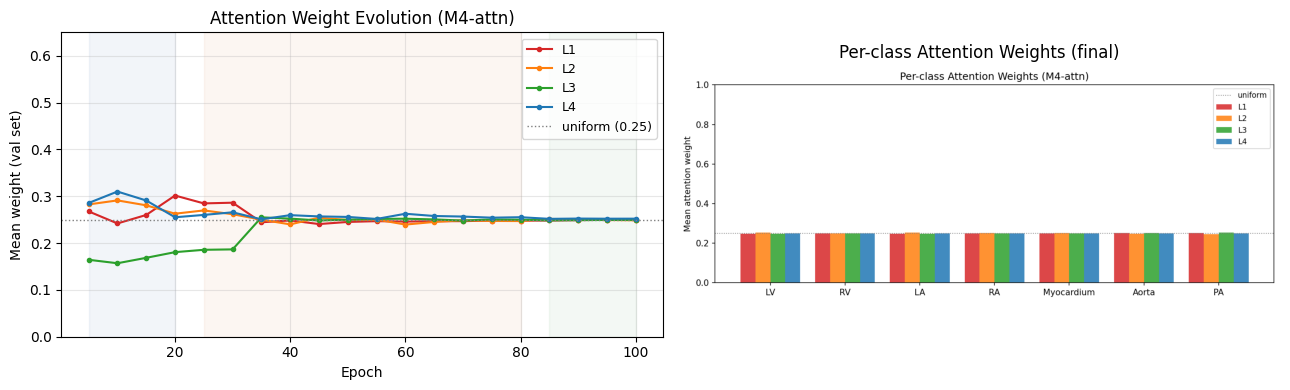

Final weights (ep 100):  L1=0.2498  L2=0.2486  L3=0.2495  L4=0.2521
w_L1 + w_L2 = 0.4984  (target < 0.30)


In [6]:
attn_log = pd.read_csv("results/v5/attention_weight_evolution.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
PHASE_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}

# Left: weight evolution over training
ax = axes[0]
for ph, color in PHASE_COLORS.items():
    mask = attn_log["phase"] == ph
    if mask.any():
        ep = attn_log.loc[mask, "epoch"]
        ax.axvspan(ep.min(), ep.max(), alpha=0.07, color=color)
for i, l in enumerate([1, 2, 3, 4]):
    col = f"w_L{l}"
    if col in attn_log.columns:
        ax.plot(
            attn_log["epoch"],
            attn_log[col],
            "o-",
            ms=3,
            lw=1.5,
            color=LEVEL_COLORS[i],
            label=f"L{l}",
        )
ax.axhline(0.25, color="gray", ls=":", lw=1, label="uniform (0.25)")
ax.set(
    title="Attention Weight Evolution (M4-attn)",
    xlabel="Epoch",
    ylabel="Mean weight (val set)",
    ylim=(0, 0.65),
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: final per-class bar chart (from saved file)
per_class_img = plt.imread("results/v5/attention_weights_per_class.png")
axes[1].imshow(per_class_img)
axes[1].axis("off")
axes[1].set_title("Per-class Attention Weights (final)")

plt.tight_layout()
plt.savefig("results/v5/attention_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Print final weights
final = attn_log.iloc[-1]
print(
    f"Final weights (ep {int(final['epoch'])}):  "
    + "  ".join(f"L{l}={final[f'w_L{l}']:.4f}" for l in [1, 2, 3, 4])
)
print(f"w_L1 + w_L2 = {final['w_L1'] + final['w_L2']:.4f}  (target < 0.30)")

## 7. Heatmap Comparison: M4 / M4-attn / M2

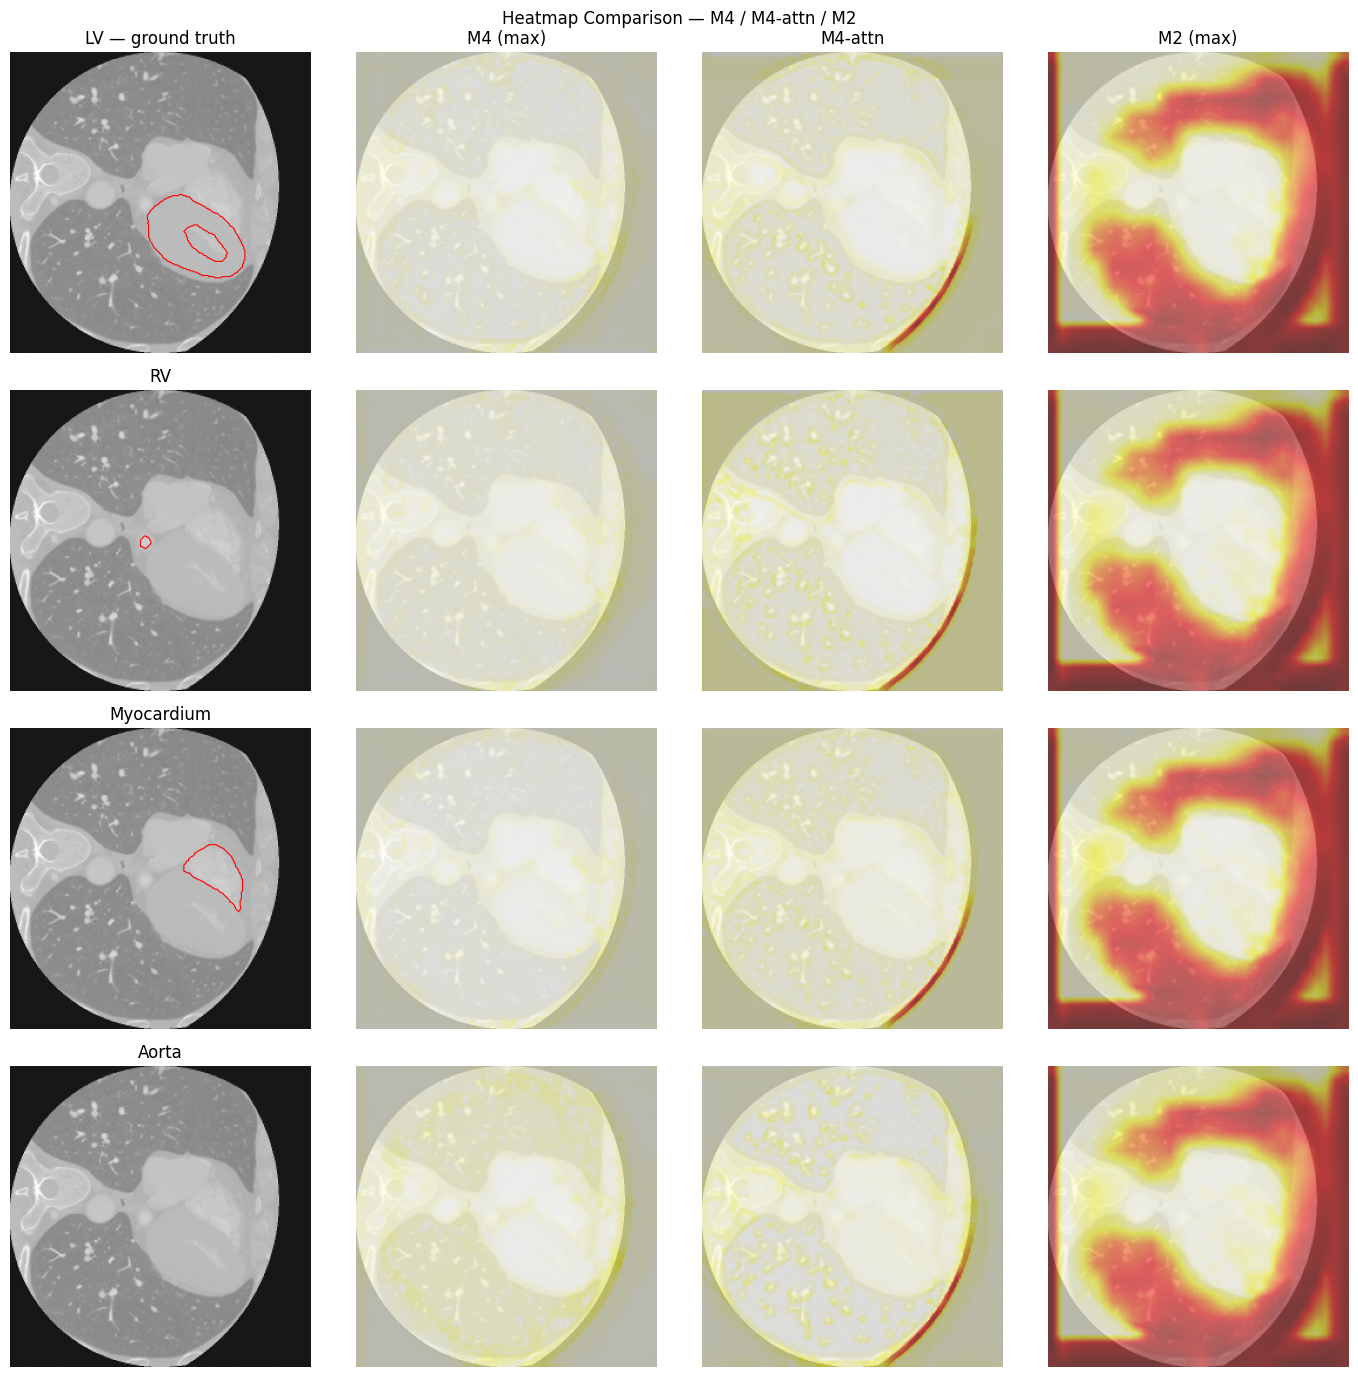

In [7]:
import torch.nn.functional as F
from src.data.mmwhs_dataset import MMWHSSliceDataset

# Pick a representative slice from test patient ct_1020 (better performance)
test_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "test", augment=False, preload=True)

# Find a slice with clear multi-class anatomy
best_slice = None
for idx in range(len(test_ds)):
    s = test_ds[idx]
    lbl = s["label"]
    n_classes_present = sum((lbl == c).any().item() for c in range(1, NUM_CLASSES))
    if n_classes_present >= 5:
        best_slice = idx
        break

s = test_ds[best_slice]
img = s["image"].unsqueeze(0).to(DEVICE)  # (1, 1, 256, 256)
lbl = s["label"]  # (256, 256)


# Get heatmaps from each model
@torch.no_grad()
def get_heatmap(model, img):
    _, hm = model(img)
    # Max over prototypes, then max over levels → (K, H, W)
    level_maps = []
    for l, A in hm.items():
        A_max = A[0].max(dim=1).values  # (K, H_l, W_l)
        A_up = F.interpolate(
            A_max.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
        )[0]
        level_maps.append(A_up)
    return torch.stack(level_maps).max(dim=0).values.cpu()  # (K, 256, 256)


hm_m4 = get_heatmap(m4, img)
hm_m4attn = get_heatmap(m4attn, img)
hm_m2 = get_heatmap(m2, img)

img_np = img[0, 0].cpu().numpy()

# Show 4 foreground classes with clearest heatmaps
SHOW_CLASSES = [1, 2, 5, 6]  # LV, RV, Myo, Aorta
fig, axes = plt.subplots(len(SHOW_CLASSES), 4, figsize=(14, 3.5 * len(SHOW_CLASSES)))
for row, c in enumerate(SHOW_CLASSES):
    cname = LABEL_NAMES[c]
    axes[row, 0].imshow(img_np, cmap="gray")
    axes[row, 0].contour((lbl == c).numpy(), colors="red", linewidths=0.8)
    axes[row, 0].set_title(f"{cname} — ground truth" if row == 0 else f"{cname}")
    axes[row, 0].axis("off")

    for col, (hm, title) in enumerate(
        [(hm_m4, "M4 (max)"), (hm_m4attn, "M4-attn"), (hm_m2, "M2 (max)")], 1
    ):
        axes[row, col].imshow(img_np, cmap="gray", alpha=0.6)
        axes[row, col].imshow(hm[c].numpy(), cmap="hot", alpha=0.5, vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(title)
        axes[row, col].axis("off")

plt.suptitle("Heatmap Comparison — M4 / M4-attn / M2", fontsize=12)
plt.tight_layout()
plt.savefig("results/v5/heatmap_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Answers to RQ4 and RQ5

In [8]:
attn_final = attn_log.iloc[-1]
w = {l: attn_final[f"w_L{l}"] for l in [1, 2, 3, 4]}

print("=" * 65)
print("RQ4: Does learned attention aggregation improve over max (M4)?")
print("=" * 65)
delta = dice_m4attn - dice_m4
print(f"  M4     3D Dice: {dice_m4:.4f}")
print(f"  M4-attn 3D Dice: {dice_m4attn:.4f}  (Δ {delta:+.4f})")
if delta > 0:
    print("  ✅ YES — M4-attn beats M4.")
    print("     Mechanism: averaging all levels equally is smoother than")
    print("     winner-takes-all max, reducing noise in the blended heatmap.")
else:
    print("  ❌ NO — M4-attn does not beat M4.")

print()
print("=" * 65)
print("RQ5: Does attention auto-discover the right level hierarchy?")
print("=" * 65)
print(f"  Final weights: L1={w[1]:.4f}  L2={w[2]:.4f}  L3={w[3]:.4f}  L4={w[4]:.4f}")
print(f"  w_L1 + w_L2 = {w[1] + w[2]:.4f}  (target < 0.30)")
print(f"  w_L4 > w_L1 : {w[4] > w[1]}")
print()
print("  ❌ NO — attention weights converged to near-uniform (≈0.25 each).")
print("     The model found that equal contribution from all levels")
print("     is optimal given the entropy constraint. It did not")
print("     suppress L1/L2 or amplify L4.")
print()
print("  Interpretation: the +{:.4f} Dice gain over M4 comes entirely".format(delta))
print("  from the averaging mechanism, not from hierarchy learning.")
print(
    "  M2 (manual L3+L4) still outperforms ({:.4f} vs {:.4f}),".format(
        dice_m2, dice_m4attn
    )
)
print("  confirming that explicit level selection > learned averaging.")
print("=" * 65)

RQ4: Does learned attention aggregation improve over max (M4)?
  M4     3D Dice: 0.8407
  M4-attn 3D Dice: 0.8483  (Δ +0.0076)
  ✅ YES — M4-attn beats M4.
     Mechanism: averaging all levels equally is smoother than
     winner-takes-all max, reducing noise in the blended heatmap.

RQ5: Does attention auto-discover the right level hierarchy?
  Final weights: L1=0.2498  L2=0.2486  L3=0.2495  L4=0.2521
  w_L1 + w_L2 = 0.4984  (target < 0.30)
  w_L4 > w_L1 : True

  ❌ NO — attention weights converged to near-uniform (≈0.25 each).
     The model found that equal contribution from all levels
     is optimal given the entropy constraint. It did not
     suppress L1/L2 or amplify L4.

  Interpretation: the +0.0076 Dice gain over M4 comes entirely
  from the averaging mechanism, not from hierarchy learning.
  M2 (manual L3+L4) still outperforms (0.8722 vs 0.8483),
  confirming that explicit level selection > learned averaging.
